# Toy notebook of ORGaNICs Traveling Waves model
This toy notebook serves as a pedagogical build-up to explain the components of the ORGaNICs traveling waves model and its mechanisms. Parameters are chosen for clarity, and do not reflect the final model's parameters.

This notebook builds the mechanisms of the model one at a time, in the order they depend on each other: a normalized neuron, time, one ORGaNICs neuron, binocular rivalry, and finally a traveling wave across a row of modules. Every equation carries its ID from `docs/notation.md` (M1-M5, O1-O4, B1-B4, A1-A3), so each function here can be read next to the corresponding line of `BinocularRivalryWavesORGaNICs_vers1.py`.

In [66]:
import numpy as np
import matplotlib.pyplot as plt

p = dict(
    sigma=0.1,
    pool=1.1)   # pedagogical values; more keys get added per section

## Section 1
A neuron is one number, its response $R$, set by its drive $E$. Division by ($\sigma$+ $E$) lets it saturate.

In [65]:
def normalize(E, sigma, pool=0.0):
    return E / (sigma + E + pool)

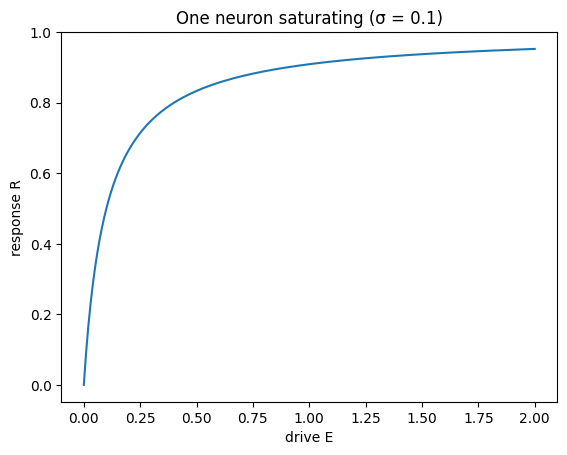

In [54]:
E = np.linspace(0, 2, 200)          # 200 drive values from 0 to 2
R = normalize(E, p["sigma"])        # one call, all 200 responses

plt.plot(E, R)
plt.axhline(1, ls="--", c="gray")   # the ceiling
plt.xlabel("drive E"); plt.ylabel("response R")
plt.title("One neuron saturating (σ = "+ str(p["sigma"]) + ")")
plt.show()

## Section 2

Neurons get quieter when their neighbours are busy. We add the neighbours' drive in the denominator as `pool`. Now the neuron's response is its own drive as a share of the total drive around it. This is divisive normalization. While this division can shrink the neurons response (e.g. through increasing pool), it will never be zero.

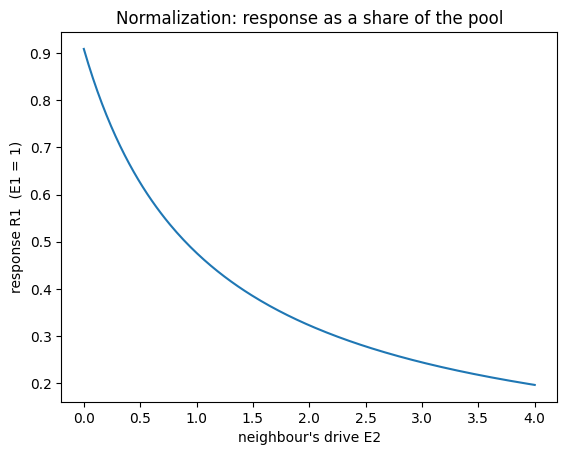

In [55]:
E2 = np.linspace(0, 4, 200)
R1 = normalize(1.0, p["sigma"], pool=E2)   # E1 = 1, neighbour's drive in the pool

plt.plot(E2, R1)
plt.xlabel("neighbour's drive E2"); plt.ylabel("response R1  (E1 = 1)")
plt.title("Normalization: response as a share of the pool")
plt.show()

## Section 3: time
Every equation in the model has the form $\tau\,\frac{dx}{dt} = -x + \text{target}$: at every time step, $x$ closes a fixed fraction of the gap to its target, and $\tau$ sets the fraction. The one-line update below (`chase`) is that rule, and it is the update line of the model's code: 
`results[..., t] = results[..., t-1] + (-results[..., t-1] + target) * dt / tau`
When $x$ has stopped moving, $x$ equals its target. So every static formula in sections 1-2 is where the dynamic version *settles*; the dynamics only add the lag.

In [ ]:
def chase(x, target, dt, tau):
    """One Euler step of tau*dx/dt = -x + target  (the form of equations M1, M3, M4, M5, ...)."""
    return x + (target - x) * dt / tau

def run_chase(tau, dt, T, target_of_t):
    """Integrate x from 0 for T ms; target_of_t(t) gives the target at time t (ms)."""
    n = int(T / dt)
    t = np.arange(n) * dt
    x = np.zeros(n)
    for k in range(1, n):
        x[k] = chase(x[k-1], target_of_t(t[k]), dt, tau) # x[k] from x[k-1] is the model's t / t-1 pattern
    return t, x

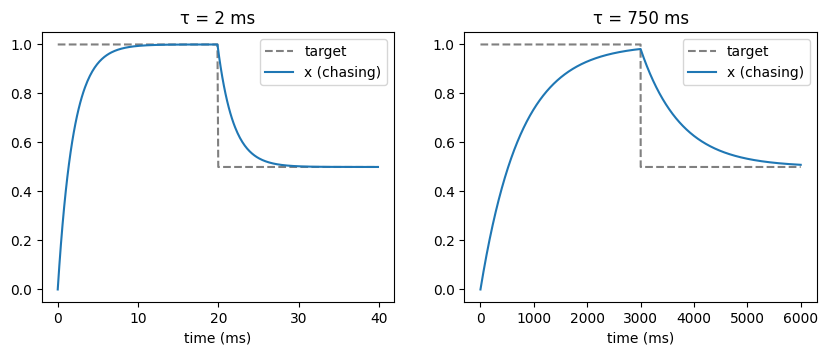

In [ ]:
dt = 0.1                                             # ms
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for a, tau, T in zip(ax, [2.0, 750.0], [40.0, 6000.0]):
    target = lambda t, T=T: 1.0 if t < T / 2 else 0.5  # a target that steps halfway through
    t, x = run_chase(tau, dt, T, target)
    a.plot(t, [target(ti) for ti in t], "--", c="gray", label="target")
    a.plot(t, x, label="x (chasing)")
    a.set_title(f"τ = {tau:g} ms"); a.set_xlabel("time (ms)"); a.legend()
plt.show()

## Section 4 - ORGaNICs Neuron
One ORGaNICs neuron has three chasers. The response $R$ chases $m\,E + a\,R$ (M1, with the input gain $b = 1$ and the recurrent drive $\hat R = R$). The recurrent gain $a$ chases $1 - (S + \sigma^n + W_H H^n)$ (M4), so one minsus the normalization denominator. The adaptation $H$ chases $R$ slowly (M5, $\tau_H = 750$ ms) which is a running average of the neurons own activity, so the neuron tires on its own firing.

In [58]:
p.update(tau_mo=2.0, tau_a=1.0, tau_H=750.0, n=2, W_H=3.5, m=1.0)

def simulate_neuron(E, p, dt=0.1, T=6000.0):
    """One ORGaNICs neuron with constant drive E: M1 (b = 1, R_hat = R), M4, M5.
    Pool S is the neuron's own drive. Returns t, R, a, H (ms, unitless)."""
    n = int(T / dt)
    t = np.arange(n) * dt
    R, a, H = np.zeros(n), np.zeros(n), np.zeros(n)
    S = E                                                        # pool = own drive
    for k in range(1, n):
        R[k] = chase(R[k-1], p["m"] * E + a[k-1] * R[k-1], dt, p["tau_mo"])            # M1
        a[k] = chase(a[k-1], 1 - (S + p["sigma"]**p["n"] + p["W_H"] * H[k-1]**p["n"]), dt, p["tau_a"])  # M4
        H[k] = chase(H[k-1], R[k-1], dt, p["tau_H"])                                    # M5
    return t, R, a, H

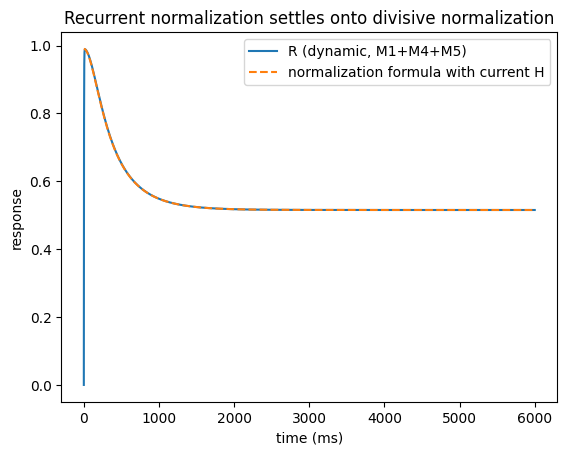

In [59]:
E = 1.0
t, R, a, H = simulate_neuron(E, p)
static = normalize(E, p["sigma"]**p["n"], pool=p["W_H"] * H**p["n"])   # section-2 formula, H(t) plugged in

plt.plot(t, R, label="R (dynamic, M1+M4+M5)")
plt.plot(t, static, "--", label="normalization formula with current H")
plt.xlabel("time (ms)"); plt.ylabel("response"); plt.legend()
plt.title("Recurrent normalization settles onto divisive normalization")
plt.show()

## Section 5: Rivalry
Two of the neurons from section 4, one per eye, each driven by its own grating. Division can't silence a neuron (section 2), so the model subtracts. Two comparator neurons (dscribed by O1-O3) measure how far each eye is ahead, and each eye's drive loses $w_o$ times the other eye's lead (M2 without the lateral terms). Whoever leads wins outright, until adaptation (M5) wears the winner down to the release condition w_o·O < Dⁿ, the loser wakes with a rested gain, and the two-inhibition loop flips the dominance in a few milliseconds.

In [60]:
p.update(w_o=3.0, n_o=1, sigma_o=1.2, tau_o=2.0, D_l=1.0, D_r=1.0, t_on_r=100.0)

def simulate_rivalry(p, dt=0.1, T=6000.0):
    """Two monocular neurons (M1, M2, M4, M5; b = 1, no lateral terms) coupled through two
    comparators (O1-O3). Each comparator's output inhibits the other eye (O4, one orientation).
    Right-eye grating switches on at t_on_r so that one eye wins first. Times in ms."""
    n = int(T / dt); t = np.arange(n) * dt
    tr = {k: np.zeros(n) for k in ("R_l", "R_r", "H_l", "H_r", "inh_l", "inh_r")}
    R_l = R_r = a_l = a_r = H_l = H_r = 0.0
    R_ol = R_or = a_ol = a_or = 0.0                       # O_l = R_ol (L-R), O_r = R_or (R-L)
    sig_n, sig_o = p["sigma"] ** p["n"], p["sigma_o"] ** p["n_o"]
    for k in range(1, n):
        D_r = p["D_r"] if t[k] >= p["t_on_r"] else 0.0
        # M2 without lateral terms: own contrast minus the other eye's comparator, clipped at zero
        E_l = max(0.0, p["D_l"] ** p["n"] - p["w_o"] * R_or)
        E_r = max(0.0, D_r ** p["n"]      - p["w_o"] * R_ol)
        # O2 and its mirror (rectified before the power, as in the code)
        E_ol = max(0.0, R_l - R_r) ** p["n_o"]
        E_or = max(0.0, R_r - R_l) ** p["n_o"]
        S, S_o = E_l + E_r, E_ol + E_or                   # pools, as in the code
        # gains: M4 for the eyes, O3 for the comparators (no adaptation term)
        a_l  = chase(a_l,  1 - (S + sig_n + p["W_H"] * H_l ** p["n"]), dt, p["tau_a"])
        a_r  = chase(a_r,  1 - (S + sig_n + p["W_H"] * H_r ** p["n"]), dt, p["tau_a"])
        a_ol = chase(a_ol, 1 - (S_o + sig_o), dt, p["tau_a"])
        a_or = chase(a_or, 1 - (S_o + sig_o), dt, p["tau_a"])
        # responses (M1, O1) and adaptation (M5); H reads the previous R, as the code does
        R_l_new = chase(R_l, p["m"] * E_l + a_l * R_l, dt, p["tau_mo"])
        R_r_new = chase(R_r, p["m"] * E_r + a_r * R_r, dt, p["tau_mo"])
        R_ol = chase(R_ol, E_ol + a_ol * R_ol, dt, p["tau_o"])
        R_or = chase(R_or, E_or + a_or * R_or, dt, p["tau_o"])
        H_l = chase(H_l, R_l, dt, p["tau_H"])
        H_r = chase(H_r, R_r, dt, p["tau_H"])
        R_l, R_r = R_l_new, R_r_new
        tr["R_l"][k], tr["R_r"][k] = R_l, R_r
        tr["H_l"][k], tr["H_r"][k] = H_l, H_r
        tr["inh_l"][k], tr["inh_r"][k] = p["w_o"] * R_or, p["w_o"] * R_ol
    tr["t"] = t
    return tr

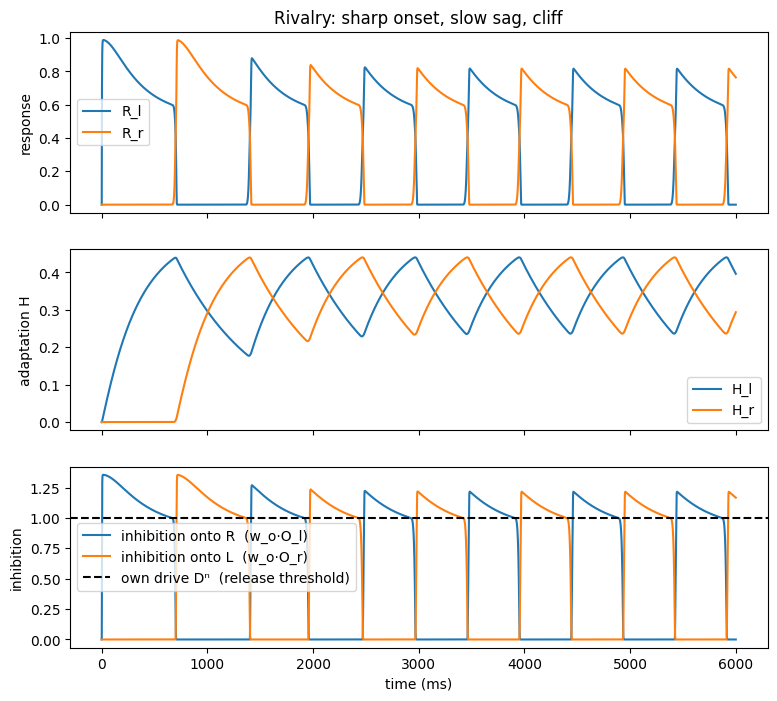

In [61]:
tr = simulate_rivalry(p); t = tr["t"]
fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
ax[0].plot(t, tr["R_l"], label="R_l"); ax[0].plot(t, tr["R_r"], label="R_r")
ax[0].set_ylabel("response"); ax[0].legend(); ax[0].set_title("Rivalry: sharp onset, slow sag, cliff")
ax[1].plot(t, tr["H_l"], label="H_l"); ax[1].plot(t, tr["H_r"], label="H_r")
ax[1].set_ylabel("adaptation H"); ax[1].legend()
ax[2].plot(t, tr["inh_r"], label="inhibition onto R  (w_o·O_l)")
ax[2].plot(t, tr["inh_l"], label="inhibition onto L  (w_o·O_r)")
ax[2].axhline(p["D_r"] ** p["n"], ls="--", c="k", label="own drive Dⁿ  (release threshold)")
ax[2].set_ylabel("inhibition"); ax[2].set_xlabel("time (ms)"); ax[2].legend()
plt.show()

The bottom panel is the release condition, where each flips happens at the instant the inhibition the suppressed eye receives falls below its own drive.

## Section 6: Wave

Everything so far happens inside one module. The wave needs a row of $N$ modules, each a section-5 pair, and one new object which is a spatial kernel 
$W_{ij} = w_o \exp(-|i-j|/\lambda)$, normalized so each module's weights sum to one. Each eye's drive now loses inhibition *gathered from all modules*, `W @ O`, which is M2's $\sum_j [w_o]_{ij}\, O_{r,j}$, and the code's `.T.dot(wo[idx])`.
Two parameter changed from sec 5, namely adaptation that is weakened (`W_H = 1.2`) and inhibition that was strengthened (`w_o = 3.5`) so that the dominant eye is stable but partly tired. If we keept section 5's parameters the whole row would alternate on its own and hide the wave. The wave is triggered my a brief contrast increase in the suppressed eye's image, here on three modules at the centre of the row.

In [62]:
p.update(W_H=1.2, w_o=3.5, N=31, lam=1.0, t_trig=2500.0, trig_dur=100.0, trig_amp=1.5, trig_width=3)

def kernel(N, lam):
    """Spatial inhibition kernel exp(-|i-j|/lam), each row normalised to sum to 1 (M2's [w_o]_ij up to w_o)."""
    d = np.abs(np.arange(N)[:, None] - np.arange(N)[None, :])
    K = np.exp(-d / lam)
    return K / K.sum(axis=1, keepdims=True)

def simulate_row(p, dt=0.1, T=4000.0):
    """Section-5 model on a row of N modules; inhibition spread by the kernel. Same update order.
    Returns t and (time x module) arrays of R_l, R_r, H_l."""
    N = p["N"]; n = int(T / dt); t = np.arange(n) * dt
    W = p["w_o"] * kernel(N, p["lam"])
    mid, half = N // 2, p["trig_width"] // 2
    R_l = np.zeros(N); R_r = np.zeros(N); a_l = np.zeros(N); a_r = np.zeros(N)
    H_l = np.zeros(N); H_r = np.zeros(N)
    R_ol = np.zeros(N); R_or = np.zeros(N); a_ol = np.zeros(N); a_or = np.zeros(N)
    sig_n, sig_o = p["sigma"] ** p["n"], p["sigma_o"] ** p["n_o"]
    RL = np.zeros((n, N)); RR = np.zeros((n, N)); HL = np.zeros((n, N))
    for k in range(1, n):
        D_r = np.full(N, p["D_r"] if t[k] >= p["t_on_r"] else 0.0)
        if p["t_trig"] <= t[k] < p["t_trig"] + p["trig_dur"]:
            D_r[mid - half: mid + half + 1] += p["trig_amp"]           # the trigger
        E_l = np.maximum(0.0, p["D_l"] ** p["n"] - W @ R_or)            # M2: inhibition from all modules
        E_r = np.maximum(0.0, D_r ** p["n"]      - W @ R_ol)
        E_ol = np.maximum(0.0, R_l - R_r) ** p["n_o"]                   # O2 and mirror
        E_or = np.maximum(0.0, R_r - R_l) ** p["n_o"]
        S, S_o = E_l + E_r, E_ol + E_or
        a_l  = chase(a_l,  1 - (S + sig_n + p["W_H"] * H_l ** p["n"]), dt, p["tau_a"])   # M4
        a_r  = chase(a_r,  1 - (S + sig_n + p["W_H"] * H_r ** p["n"]), dt, p["tau_a"])
        a_ol = chase(a_ol, 1 - (S_o + sig_o), dt, p["tau_a"])                             # O3
        a_or = chase(a_or, 1 - (S_o + sig_o), dt, p["tau_a"])
        R_l_new = chase(R_l, p["m"] * E_l + a_l * R_l, dt, p["tau_mo"])                   # M1
        R_r_new = chase(R_r, p["m"] * E_r + a_r * R_r, dt, p["tau_mo"])
        R_ol = chase(R_ol, E_ol + a_ol * R_ol, dt, p["tau_o"])                            # O1
        R_or = chase(R_or, E_or + a_or * R_or, dt, p["tau_o"])
        H_l = chase(H_l, R_l, dt, p["tau_H"]); H_r = chase(H_r, R_r, dt, p["tau_H"])    # M5
        R_l, R_r = R_l_new, R_r_new
        RL[k], RR[k], HL[k] = R_l, R_r, H_l
    return t, RL, RR, HL

def switch_delay(t, RL, RR, t_trig):
    """Per module: first time after the trigger at which R_r > R_l, relative to the trigger (nan = never)."""
    out = np.full(RL.shape[1], np.nan)
    after = t >= t_trig
    for i in range(RL.shape[1]):
        hit = np.where(after & (RR[:, i] > RL[:, i]))[0]
        if len(hit): out[i] = t[hit[0]] - t_trig
    return out

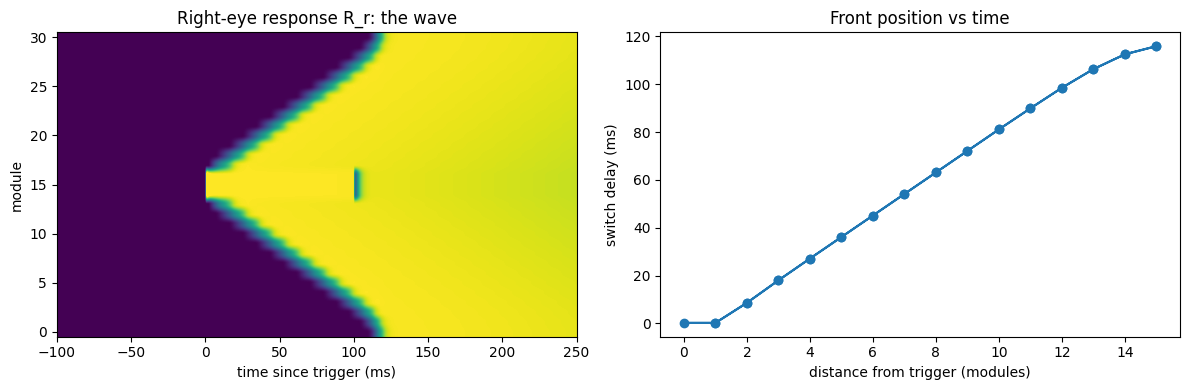

In [63]:
t, RL, RR, HL = simulate_row(p)
delay = switch_delay(t, RL, RR, p["t_trig"])
mid = p["N"] // 2
dist = np.abs(np.arange(p["N"]) - mid)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
win = (t >= p["t_trig"] - 100) & (t <= p["t_trig"] + 250)
ax[0].imshow(RR[win].T, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1,
             extent=[t[win][0] - p["t_trig"], t[win][-1] - p["t_trig"], -0.5, p["N"] - 0.5])
ax[0].set_xlabel("time since trigger (ms)"); ax[0].set_ylabel("module"); ax[0].set_title("Right-eye response R_r: the wave")
ax[1].plot(dist, delay, "o-")
ax[1].set_xlabel("distance from trigger (modules)"); ax[1].set_ylabel("switch delay (ms)"); ax[1].set_title("Front position vs time")
plt.tight_layout(); plt.show()

The V in the left panel is the wave. The flipped patch pushes its neighbours past their release condition, they push theirs, and the front travels outward at a constant speed. The small notch at the centre at 100 ms is the trigger ending, as the wave no longer needs it. The bend in the last two or three points is an edge effect that occurrs because the outmost modules have neighbours on one side only, so the row-normalized kernel gives them more self-weight and they are slightly harder to tip.